## Imports

In [2]:
from typing import List, Tuple, Optional, Dict, NamedTuple, Union, Callable
import itertools
import os
import string
from pathlib import Path

import numpy as np
import torch
from scipy.spatial.distance import squareform, pdist, cdist
import matplotlib.pyplot as plt
import matplotlib as mpl
from Bio import SeqIO
import biotite.structure as bs

from biotite.structure.io.pdb import PDBFile, get_structure

from biotite.database import rcsb

from tqdm import tqdm
import pandas as pd

import esm

torch.set_grad_enabled(False)

## Define Functions

### Parsing alignments

In [3]:
# This is an efficient way to delete lowercase characters and insertion characters from a string
deletekeys = dict.fromkeys(string.ascii_lowercase)
deletekeys["."] = None
deletekeys["*"] = None
translation = str.maketrans(deletekeys)

def read_sequence(filename: str) -> Tuple[str, str]:
    """ Reads the first (reference) sequences from a fasta or MSA file."""
    record = next(SeqIO.parse(filename, "fasta"))
    return record.description, str(record.seq)

def remove_insertions(sequence: str) -> str:
    """ Removes any insertions into the sequence. Needed to load aligned sequences in an MSA. """
    return sequence.translate(translation)

def read_msa(filename: str) -> List[Tuple[str, str]]:
    """ Reads the sequences from an MSA file, automatically removes insertions."""
    return [(record.description, remove_insertions(str(record.seq))) for record in SeqIO.parse(filename, "fasta")]

### Converting structures to contacts

There are many ways to define a protein contact. Here we're using the definition of 8 angstroms between carbon beta atoms. Note that the position of the carbon beta is imputed from the position of the N, CA, and C atoms for each residue.

In [4]:
def extend(a, b, c, L, A, D):
    """
    input:  3 coords (a,b,c), (L)ength, (A)ngle, and (D)ihedral
    output: 4th coord
    """

    def normalize(x):
        return x / np.linalg.norm(x, ord=2, axis=-1, keepdims=True)

    bc = normalize(b - c)
    n = normalize(np.cross(b - a, bc))
    m = [bc, np.cross(n, bc), n]
    d = [L * np.cos(A), L * np.sin(A) * np.cos(D), -L * np.sin(A) * np.sin(D)]
    return c + sum([m * d for m, d in zip(m, d)])


def contacts_from_pdb(
    structure: bs.AtomArray,
    distance_threshold: float = 8.0,
    chain: Optional[str] = None,
) -> np.ndarray:
    mask = ~structure.hetero
    if chain is not None:
        mask &= structure.chain_id == chain

    N = structure.coord[mask & (structure.atom_name == "N")]
    CA = structure.coord[mask & (structure.atom_name == "CA")]
    C = structure.coord[mask & (structure.atom_name == "C")]

    Cbeta = extend(C, N, CA, 1.522, 1.927, -2.143)
    dist = squareform(pdist(Cbeta))
    
    contacts = dist < distance_threshold
    contacts = contacts.astype(np.int64)
    contacts[np.isnan(dist)] = -1
    return contacts

### Compute contact precisions

In [5]:
def compute_precisions(
    predictions: torch.Tensor,
    targets: torch.Tensor,
    src_lengths: Optional[torch.Tensor] = None,
    minsep: int = 6,
    maxsep: Optional[int] = None,
    override_length: Optional[int] = None,  # for casp
):
    if isinstance(predictions, np.ndarray):
        predictions = torch.from_numpy(predictions)
    if isinstance(targets, np.ndarray):
        targets = torch.from_numpy(targets)
    if predictions.dim() == 2:
        predictions = predictions.unsqueeze(0)
    if targets.dim() == 2:
        targets = targets.unsqueeze(0)
    override_length = (targets[0, 0] >= 0).sum()

    # Check sizes
    if predictions.size() != targets.size():
        raise ValueError(
            f"Size mismatch. Received predictions of size {predictions.size()}, "
            f"targets of size {targets.size()}"
        )
    device = predictions.device

    batch_size, seqlen, _ = predictions.size()
    seqlen_range = torch.arange(seqlen, device=device)

    sep = seqlen_range.unsqueeze(0) - seqlen_range.unsqueeze(1)
    sep = sep.unsqueeze(0)
    valid_mask = sep >= minsep
    valid_mask = valid_mask & (targets >= 0)  # negative targets are invalid

    if maxsep is not None:
        valid_mask &= sep < maxsep

    if src_lengths is not None:
        valid = seqlen_range.unsqueeze(0) < src_lengths.unsqueeze(1)
        valid_mask &= valid.unsqueeze(1) & valid.unsqueeze(2)
    else:
        src_lengths = torch.full([batch_size], seqlen, device=device, dtype=torch.long)

    predictions = predictions.masked_fill(~valid_mask, float("-inf"))

    x_ind, y_ind = np.triu_indices(seqlen, minsep)
    predictions_upper = predictions[:, x_ind, y_ind]
    targets_upper = targets[:, x_ind, y_ind]

    topk = seqlen if override_length is None else max(seqlen, override_length)
    indices = predictions_upper.argsort(dim=-1, descending=True)[:, :topk]
    topk_targets = targets_upper[torch.arange(batch_size).unsqueeze(1), indices]
    if topk_targets.size(1) < topk:
        topk_targets = F.pad(topk_targets, [0, topk - topk_targets.size(1)])

    cumulative_dist = topk_targets.type_as(predictions).cumsum(-1)

    gather_lengths = src_lengths.unsqueeze(1)
    if override_length is not None:
        gather_lengths = override_length * torch.ones_like(
            gather_lengths, device=device
        )

    gather_indices = (
        torch.arange(0.1, 1.1, 0.1, device=device).unsqueeze(0) * gather_lengths
    ).type(torch.long) - 1

    binned_cumulative_dist = cumulative_dist.gather(1, gather_indices)
    binned_precisions = binned_cumulative_dist / (gather_indices + 1).type_as(
        binned_cumulative_dist
    )

    pl5 = binned_precisions[:, 1]
    pl2 = binned_precisions[:, 4]
    pl = binned_precisions[:, 9]
    auc = binned_precisions.mean(-1)

    return {"AUC": auc, "P@L": pl, "P@L2": pl2, "P@L5": pl5}


def evaluate_prediction(
    predictions: torch.Tensor,
    targets: torch.Tensor,
) -> Dict[str, float]:
    if isinstance(targets, np.ndarray):
        targets = torch.from_numpy(targets)
    contact_ranges = [
        ("local", 3, 6),
        ("short", 6, 12),
        ("medium", 12, 24),
        ("long", 24, None),
    ]
    metrics = {}
    targets = targets.to(predictions.device)
    for name, minsep, maxsep in contact_ranges:
        rangemetrics = compute_precisions(
            predictions,
            targets,
            minsep=minsep,
            maxsep=maxsep,
        )
        for key, val in rangemetrics.items():
            metrics[f"{name}_{key}"] = val.item()
    return metrics

### Plotting Results

In [6]:
"""Adapted from: https://github.com/rmrao/evo/blob/main/evo/visualize.py"""
def plot_contacts_and_predictions(
    predictions: Union[torch.Tensor, np.ndarray],
    contacts: Union[torch.Tensor, np.ndarray],
    ax: Optional[mpl.axes.Axes] = None,
    # artists: Optional[ContactAndPredictionArtists] = None,
    cmap: str = "Blues",
    ms: float = 1,
    title: Union[bool, str, Callable[[float], str]] = True,
    animated: bool = False,
) -> None:

    if isinstance(predictions, torch.Tensor):
        predictions = predictions.detach().cpu().numpy()
    if isinstance(contacts, torch.Tensor):
        contacts = contacts.detach().cpu().numpy()
    if ax is None:
        ax = plt.gca()

    seqlen = contacts.shape[0]
    relative_distance = np.add.outer(-np.arange(seqlen), np.arange(seqlen))
    bottom_mask = relative_distance < 0
    masked_image = np.ma.masked_where(bottom_mask, predictions)
    invalid_mask = np.abs(np.add.outer(np.arange(seqlen), -np.arange(seqlen))) < 6
    predictions = predictions.copy()
    predictions[invalid_mask] = float("-inf")

    topl_val = np.sort(predictions.reshape(-1))[-seqlen]
    pred_contacts = predictions >= topl_val
    true_positives = contacts & pred_contacts & ~bottom_mask
    false_positives = ~contacts & pred_contacts & ~bottom_mask
    other_contacts = contacts & ~pred_contacts & ~bottom_mask

    if isinstance(title, str):
        title_text: Optional[str] = title
    elif title:
        long_range_pl = compute_precisions(predictions, contacts, minsep=24)[
            "P@L"
        ].item()
        if callable(title):
            title_text = title(long_range_pl)
        else:
            title_text = f"Long Range P@L: {100 * long_range_pl:0.1f}"
    else:
        title_text = None

    img = ax.imshow(masked_image, cmap=cmap, animated=animated)
    oc = ax.plot(*np.where(other_contacts), "o", c="grey", ms=ms)[0]
    fn = ax.plot(*np.where(false_positives), "o", c="r", ms=ms)[0]
    tp = ax.plot(*np.where(true_positives), "o", c="b", ms=ms)[0]
    ti = ax.set_title(title_text) if title_text is not None else None
    # artists = ContactAndPredictionArtists(img, oc, fn, tp, ti)

    ax.axis("square")
    ax.set_xlim([0, seqlen])
    ax.set_ylim([0, seqlen])

## Predict and Visualize

### Read Data

### Read in data from own dir --ARK

## Load model first

In [7]:
esm2, esm2_alphabet = esm.pretrained.esm2_t33_650M_UR50D()
esm2 = esm2.eval().cuda()
esm2_batch_converter = esm2_alphabet.get_batch_converter()

In [15]:
import os

esm2_predictions = {}
esm2_results = []

cp_dir = "/home/ubuntu/esm/esm/1AGY_CP"

PDB_IDS = [
    os.path.splitext(f)[0]
    for f in sorted(os.listdir(cp_dir))
    if f.endswith(".pdb")
]

structures = {
    name: get_structure(PDBFile.read(os.path.join(cp_dir, f"{name}.pdb")))[0]
    for name in PDB_IDS
}
contacts = {
    name: contacts_from_pdb(structure, chain="A")
    for name, structure in structures.items()
}
msas = {
    name: read_msa(os.path.join(cp_dir, f"{name}.fasta"))
    for name in PDB_IDS
}
sequences = {
    name: msa[0] for name, msa in msas.items()
}

for name, inputs in sequences.items():
    print(name)
    esm2_batch_labels, esm2_batch_strs, esm2_batch_tokens = esm2_batch_converter([inputs])
    esm2_batch_tokens = esm2_batch_tokens.to(next(esm2.parameters()).device)
    esm2_predictions[name] = esm2.predict_contacts(esm2_batch_tokens)[0].cpu()
    metrics = {"id": name, "model": "ESM-2 (Unsupervised)"}
    metrics.update(evaluate_prediction(esm2_predictions[name], contacts[name]))
    esm2_results.append(metrics)

print(f"Processed {len(PDB_IDS)} structures")

esm2_results = pd.DataFrame(esm2_results)
display(esm2_results)

cut0000_ptm0.933_r3
cut0001_ptm0.936_r3
cut0002_ptm0.934_r3
cut0003_ptm0.929_r3
cut0004_ptm0.927_r3
cut0005_ptm0.922_r3
cut0006_ptm0.919_r3
cut0007_ptm0.917_r3
cut0008_ptm0.935_r3
cut0009_ptm0.923_r3
cut0010_ptm0.897_r3
cut0011_ptm0.898_r3
cut0012_ptm0.901_r3
cut0013_ptm0.900_r3
cut0014_ptm0.899_r3
cut0015_ptm0.898_r3
cut0016_ptm0.931_r3
cut0017_ptm0.887_r3
cut0018_ptm0.880_r3
cut0019_ptm0.872_r3
cut0020_ptm0.919_r3
cut0021_ptm0.923_r3
cut0022_ptm0.921_r3
cut0023_ptm0.925_r3
cut0024_ptm0.924_r3
cut0025_ptm0.911_r3
cut0026_ptm0.912_r3
cut0027_ptm0.917_r3
cut0028_ptm0.919_r3
cut0029_ptm0.921_r3
cut0030_ptm0.921_r3
cut0031_ptm0.918_r3
cut0032_ptm0.907_r3
cut0033_ptm0.918_r3
cut0034_ptm0.911_r3
cut0035_ptm0.908_r3
cut0036_ptm0.906_r3
cut0037_ptm0.901_r3
cut0038_ptm0.892_r3
cut0039_ptm0.895_r3
cut0040_ptm0.891_r3
cut0041_ptm0.883_r3
cut0042_ptm0.882_r3
cut0043_ptm0.889_r3
cut0044_ptm0.871_r3
cut0045_ptm0.895_r3
cut0046_ptm0.881_r3
cut0047_ptm0.895_r3
cut0048_ptm0.898_r3
cut0049_ptm0.889_r3


,id,model,local_AUC,local_P@L,local_P@L2,local_P@L5,short_AUC,short_P@L,short_P@L2,short_P@L5,medium_AUC,medium_P@L,medium_P@L2,medium_P@L5,long_AUC,long_P@L,long_P@L2,long_P@L5
0,cut0000_ptm0.933_r3,ESM-2 (Unsupervised),0.734694,0.640,0.75,0.825,0.389117,0.210,0.34,0.550,0.541881,0.315,0.53,0.800,0.864700,0.725,0.91,0.975
1,cut0001_ptm0.936_r3,ESM-2 (Unsupervised),0.735649,0.630,0.75,0.850,0.397810,0.215,0.35,0.575,0.548026,0.320,0.53,0.800,0.865492,0.725,0.92,0.975
2,cut0002_ptm0.934_r3,ESM-2 (Unsupervised),0.722587,0.620,0.74,0.800,0.397254,0.215,0.35,0.575,0.554671,0.325,0.56,0.825,0.868117,0.730,0.91,0.975
3,cut0003_ptm0.929_r3,ESM-2 (Unsupervised),0.723651,0.620,0.73,0.800,0.405004,0.220,0.36,0.575,0.552421,0.325,0.55,0.825,0.865540,0.730,0.90,0.975
4,cut0004_ptm0.927_r3,ESM-2 (Unsupervised),0.719762,0.620,0.73,0.850,0.399829,0.225,0.36,0.575,0.562171,0.325,0.56,0.850,0.867992,0.735,0.91,0.975
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,cut0195_ptm0.920_r3,ESM-2 (Unsupervised),0.713623,0.630,0.71,0.825,0.387312,0.210,0.34,0.550,0.546798,0.320,0.52,0.825,0.864909,0.725,0.91,0.975
196,cut0196_ptm0.924_r3,ESM-2 (Unsupervised),0.728496,0.625,0.73,0.800,0.387812,0.215,0.34,0.550,0.543881,0.320,0.52,0.825,0.864320,0.720,0.91,0.975
197,cut0197_ptm0.929_r3,ESM-2 (Unsupervised),0.757028,0.645,0.76,0.875,0.390867,0.215,0.34,0.550,0.542548,0.315,0.52,0.800,0.870101,0.730,0.91,0.975
198,cut0198_ptm0.932_r3,ESM-2 (Unsupervised),0.754597,0.645,0.76,0.900,0.388436,0.215,0.34,0.550,0.541881,0.315,0.53,0.800,0.861313,0.720,0.91,0.975


In [16]:
esm2_results.to_csv("1AGY_synCP_PAL.csv", index=False)

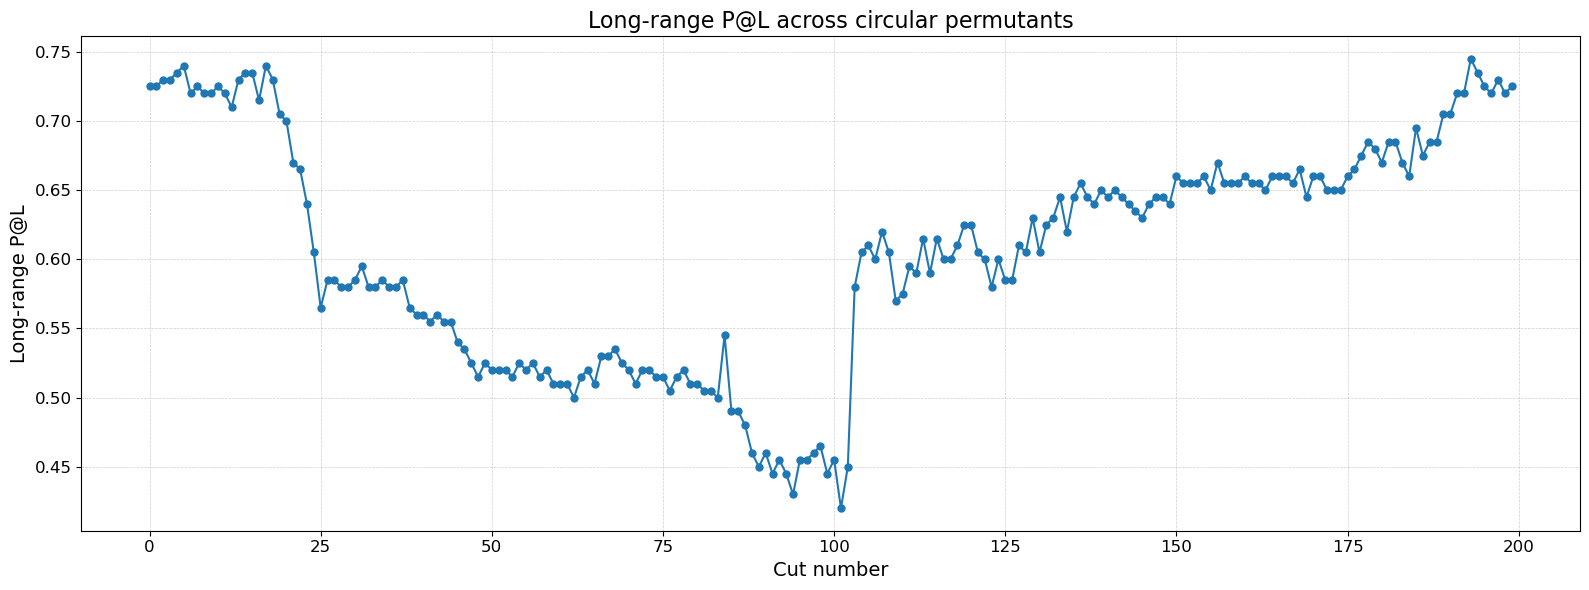

In [17]:
import re

# Extract integer cut number from the id column
esm2_results["cut_num"] = esm2_results["id"].str.extract(r"cut(\d+)").astype(int)

fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(esm2_results["cut_num"], esm2_results["long_P@L"], marker="o", linewidth=1.5, markersize=5)

ax.set_xlabel("Cut number", fontsize=14)
ax.set_ylabel("Long-range P@L", fontsize=14)
ax.set_title("Long-range P@L across circular permutants", fontsize=16)
ax.tick_params(axis="both", labelsize=12)
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)

plt.tight_layout()
#plt.savefig("long_pal_vs_cut.png", dpi=150, bbox_inches="tight")
plt.show()

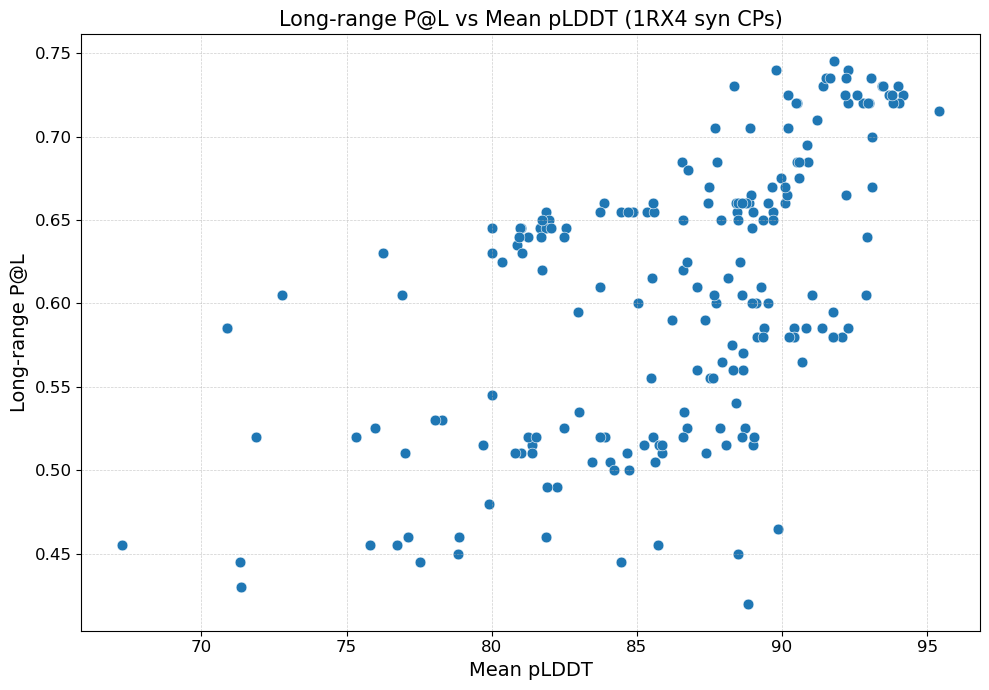

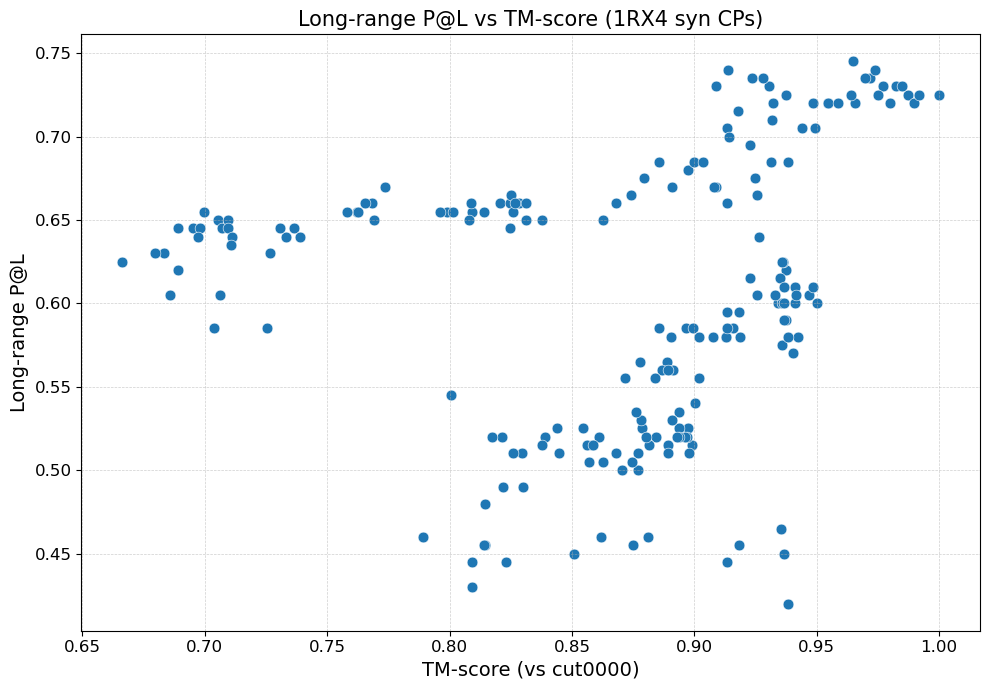

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Load both results
tm_df = pd.read_csv("~/esm/esm/1AGY_CP/tmalign/tm_plddt_results.tsv", sep="\t")
pal_df = pd.read_csv("1AGY_synCP_PAL.csv")

# Extract cut id to match on (tm_df has e.g. "cut0000", pal_df has "cut0000_ptm0.920_r3")
pal_df["cut"] = pal_df["id"].str.extract(r"(cut\d+)")

# Merge
combined = pd.merge(tm_df, pal_df, on="cut")

# ── Plot 1: P@L vs pLDDT ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(combined["mean_plddt"], combined["long_P@L"], s=60, edgecolors="white", linewidths=0.4)
ax.set_xlabel("Mean pLDDT", fontsize=14)
ax.set_ylabel("Long-range P@L", fontsize=14)
ax.set_title("Long-range P@L vs Mean pLDDT (1RX4 syn CPs)", fontsize=15)
ax.tick_params(labelsize=12)
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
plt.tight_layout()
#plt.savefig("PAL_vs_plddt.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Plot 2: P@L vs TM-score ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(combined["tm_score"], combined["long_P@L"], s=60, edgecolors="white", linewidths=0.4)
ax.set_xlabel("TM-score (vs cut0000)", fontsize=14)
ax.set_ylabel("Long-range P@L", fontsize=14)
ax.set_title("Long-range P@L vs TM-score (1RX4 syn CPs)", fontsize=15)
ax.tick_params(labelsize=12)
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
plt.tight_layout()
#plt.savefig("PAL_vs_tmscore.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
pairs = {}
ids = esm2_results["id"].tolist()

for i in range(0, len(ids), 2):
    a, b = ids[i], ids[i+1]
    if "engCP" in a:
        pairs[a] = b  # engCP -> wildtype
    else:
        pairs[b] = a  # engCP -> wildtype

pairs

{'2CNA_engCP': '6XT6',
 '3LB9_engCP': '1BCX',
 '2JGS_engCP': '7ZN1',
 '3DA7_engCP': '1A2P',
 '2O4W_engCP': '261L',
 '4RNX_engCP': '1OYA',
 '3P28_engCP': '8JL2',
 '6AHW_engCP': '1J85',
 '8B6P_engCP': '6ZCC',
 '1UN2_engCP': '1BQ7',
 '4RNU_engCP': '1OYA'}

In [12]:
from pathlib import Path
import numpy as np

engCP_dir = Path("/home/ubuntu/engCPs")
pair_dirs = sorted([d for d in engCP_dir.iterdir() if d.is_dir()])

In [13]:
pair_dirs

[PosixPath('/home/ubuntu/engCPs/DsbA'),
 PosixPath('/home/ubuntu/engCPs/GFP'),
 PosixPath('/home/ubuntu/engCPs/HaloTag'),
 PosixPath('/home/ubuntu/engCPs/avidin'),
 PosixPath('/home/ubuntu/engCPs/barnase'),
 PosixPath('/home/ubuntu/engCPs/conA'),
 PosixPath('/home/ubuntu/engCPs/methyltransferase'),
 PosixPath('/home/ubuntu/engCPs/old_yellow_enzyme_1'),
 PosixPath('/home/ubuntu/engCPs/old_yellow_enzyme_2'),
 PosixPath('/home/ubuntu/engCPs/t4_lysozyme'),
 PosixPath('/home/ubuntu/engCPs/xylanase')]

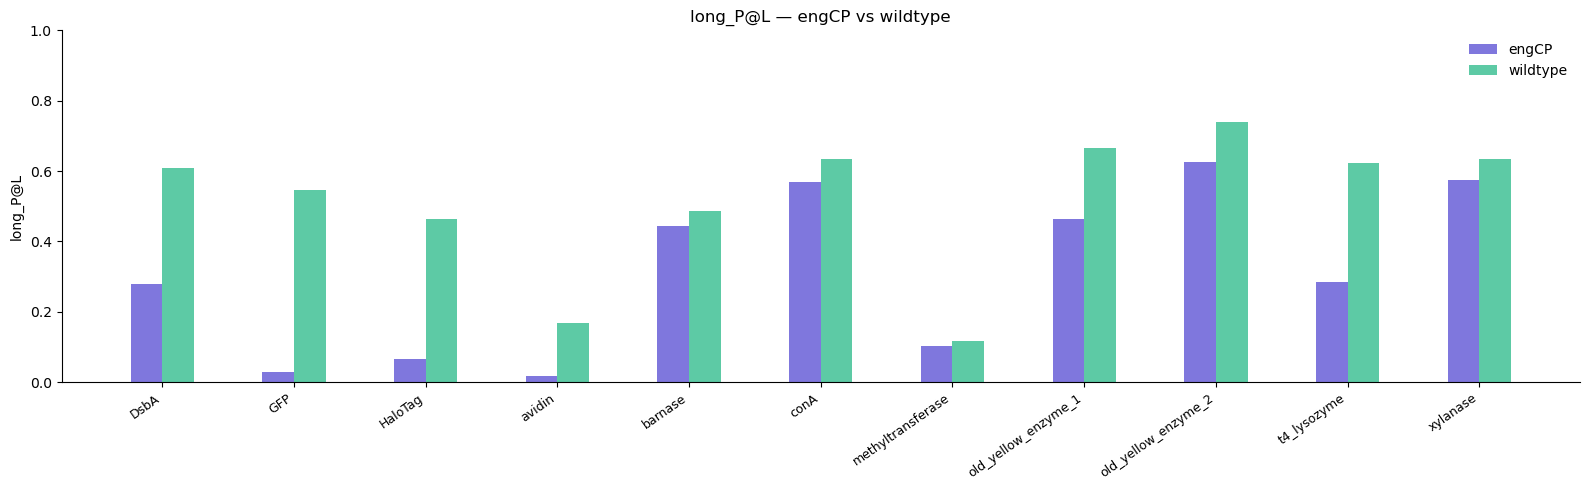

In [16]:
labels = [d.name for d in pair_dirs]

metric = "long_P@L"

engcp_vals = [esm2_results.loc[esm2_results["id"] == k, metric].values[0] for k in pairs]
wt_vals    = [esm2_results.loc[esm2_results["id"] == v, metric].values[0] for v in pairs.values()]

# directory names as labels
labels = [Path(p).name for p in pair_dirs]

x = np.arange(len(labels)) * 0.75
w = 0.18

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(x - w/2, engcp_vals, width=w, color="#7F77DD", label="engCP")
ax.bar(x + w/2, wt_vals,    width=w, color="#5DCAA5", label="wildtype")

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=9)
ax.set_ylim(0, 1)
ax.set_ylabel(metric)
ax.set_title(f"{metric} — engCP vs wildtype")

ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig('engCP_long_range_pL.png')
plt.show()

### ESM-2 Predictions

In [ ]:

for name, inputs in sequences.items():
    esm2_batch_labels, esm2_batch_strs, esm2_batch_tokens = esm2_batch_converter([inputs])
    esm2_batch_tokens = esm2_batch_tokens.to(next(esm2.parameters()).device)
    esm2_predictions[name] = esm2.predict_contacts(esm2_batch_tokens)[0].cpu()
    metrics = {"id": name, "model": "ESM-2 (Unsupervised)"}
    metrics.update(evaluate_prediction(esm2_predictions[name], contacts[name]))
    esm2_results.append(metrics)
esm2_results = pd.DataFrame(esm2_results)
display(esm2_results)

In [ ]:
fig, axes = plt.subplots(figsize=(18, 6), ncols=2)
for ax, name in zip(axes, PDB_IDS):
    prediction = esm2_predictions[name]
    target = contacts[name]
    plot_contacts_and_predictions(
        prediction, target, ax=ax, title = lambda prec: f"{name}: Long Range P@L: {100 * prec:0.1f}"
    )
plt.show()

### MSA Transformer Predictions

In [ ]:
msa_transformer, msa_transformer_alphabet = esm.pretrained.esm_msa1b_t12_100M_UR50S()
msa_transformer = msa_transformer.eval().cuda()
msa_transformer_batch_converter = msa_transformer_alphabet.get_batch_converter()

In [ ]:
# Clear up memory
esm2=esm2.to("cpu")
import gc
gc.collect()
torch.cuda.empty_cache()

In [ ]:
msa_transformer_predictions = {}
msa_transformer_results = []
for name, inputs in msas.items():
    inputs = greedy_select(inputs, num_seqs=128) # can change this to pass more/fewer sequences
    msa_transformer_batch_labels, msa_transformer_batch_strs, msa_transformer_batch_tokens = msa_transformer_batch_converter([inputs])
    msa_transformer_batch_tokens = msa_transformer_batch_tokens.to(next(msa_transformer.parameters()).device)
    msa_transformer_predictions[name] = msa_transformer.predict_contacts(msa_transformer_batch_tokens)[0].cpu()
    metrics = {"id": name, "model": "MSA Transformer (Unsupervised)"}
    metrics.update(evaluate_prediction(msa_transformer_predictions[name], contacts[name]))
    msa_transformer_results.append(metrics)
msa_transformer_results = pd.DataFrame(msa_transformer_results)
display(msa_transformer_results)

In [ ]:
fig, axes = plt.subplots(figsize=(18, 6), ncols=3)
for ax, name in zip(axes, PDB_IDS):
    prediction = msa_transformer_predictions[name]
    target = contacts[name]
    plot_contacts_and_predictions(
        prediction, target, ax=ax, title = lambda prec: f"{name}: Long Range P@L: {100 * prec:0.1f}"
    )
plt.show()